In this notebook I want to study $dg$-algebras. The main example will be the Koszul DG algebra $A=\mathbb{F}_p[x_1,\ldots,x_n]/(x_1^q,\ldots,x_n^q)\otimes \Lambda(\theta_1,\ldots,\theta_n)$. With the expected differential $d(x_i)=0$ and $d(\theta_i)=x_i$.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import random
from torch.utils.data import TensorDataset, DataLoader, random_split
import itertools

import matplotlib.pyplot as plt

import os
import sys

random.seed(0)
pair_seed = 420

module_path = os.path.abspath(".")
if module_path not in sys.path:
    sys.path.append(module_path)

dtype = torch.float32

############## Use GPU ##############
USE_GPU = True
#####################################
if USE_GPU == True and torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
print('using device:', device)

using device: cuda


In [35]:
class DGModel(nn.Module):
    def __init__(self, D, p, emb_dim=128, hid_dim=512, n_ops=2, std=0.1):
        super().__init__()

        self.elem_emb = nn.Embedding(D + 1, emb_dim)  # +1 for dummy
        self.op_emb = nn.Embedding(n_ops, emb_dim)

        self.fc1=nn.Linear(3*emb_dim, hid_dim)
        self.out=nn.Linear(hid_dim,D*p)

        nn.init.normal_(self.elem_emb.weight, mean=0.0, std=std)
        nn.init.normal_(self.op_emb.weight, mean=0.0, std=std)
        nn.init.normal_(self.fc1.weight, mean=0.0, std=std)
        nn.init.normal_(self.out.weight, mean=0.0, std=std)
        
        self.std=std
        self.D = D
        self.p = p

    def forward(self, op, left, right):
        op_e = self.op_emb(op)
        left_e = self.elem_emb(left)
        right_e = self.elem_emb(right)

        h = torch.cat([op_e, left_e, right_e], dim=-1)
        end = self.out(torch.relu(self.fc1(h)))

        return end.view(-1, self.D, self.p) #[batch, D, p]

In [77]:
class DGMultFeatureModel(nn.Module):
    def __init__(self, D, p, hid_dim=128, std=0.01):
        super().__init__()
        self.D = D
        self.p = p

        

        self.fc1=nn.Linear(8, hid_dim)
        self.out=nn.Linear(hid_dim,D*p)

        nn.init.normal_(self.fc1.weight, mean=0.0, std=std)
        nn.init.normal_(self.out.weight, mean=0.0, std=std)


    def forward(self, left_feat, right_feat):
        x = torch.cat([left_feat, right_feat], dim=-1).float()
        ot = self.out(torch.relu(self.fc1(x)))
        return ot.view(-1, self.D, self.p)


I will do this for $p=5,\ q=5,\ n=2$.

In [6]:
#because there is no canonical way of identifying the order of elements, build the explicit indexing, where each basis element is a tuple with 
#the first two powers being the bosonic ones and the last two the fermionic
def build_basis_tensor(q=5, device="cpu"):
    vals = torch.cartesian_prod(
        torch.arange(q, device=device),
        torch.arange(q, device=device),
        torch.arange(2, device=device),
        torch.arange(2, device=device),
    )
    # columns: a1, a2, e1, e2
    return vals.long()

def basis_index_tensor(a1, a2, e1, e2, q):
    return (((a1 * q + a2) * 2 + e1) * 2 + e2).long()



def build_mul_targets_tensor(basis, p=5, q=5):
    device = basis.device
    D = basis.shape[0]

    left = basis[:, None, :]   # [D, 1, 4]
    right = basis[None, :, :]  # [1, D, 4]

    a1 = left[..., 0] #[D,1]
    a2 = left[..., 1] #[D,1]
    e1 = left[..., 2] #[D,1]
    e2 = left[..., 3] #[D,1]

    b1 = right[..., 0] #[1,D]
    b2 = right[..., 1] #[1,D]
    f1 = right[..., 2] #[1,D]
    f2 = right[..., 3] #[1,D]

    c1 = a1 + b1 #[D,D]
    c2 = a2 + b2 #[D,D]

    g1 = e1 + f1 #[D,D]
    g2 = e2 + f2 #[D,D]

    valid = (c1 < q) & (c2 < q) & (g1 < 2) & (g2 < 2) #[D,D]; basically here are the non-zero basis elements

    # exterior sign: theta2 from left crossing theta1 from right
    inversions = e2 * f1 #[D,D]
    coeff = torch.ones_like(c1)
    coeff[inversions % 2 == 1] = p - 1

    out_idx = basis_index_tensor(c1.clamp(max=q-1), c2.clamp(max=q-1), g1.clamp(max=1), g2.clamp(max=1), q) #[D,D]; for each combination of elements return the index of the product

    targets = torch.zeros(D, D, D, dtype=torch.long, device=device)

    ii, jj = torch.where(valid) #this is a boolean [D,D] where the True values are for pairs whose product is non-zero
    targets[ii, jj, out_idx[ii, jj]] = coeff[ii, jj] % p

    return targets

def build_diff_targets_tensor(basis, p=5, q=5):
    device = basis.device
    D = basis.shape[0]

    a1 = basis[:, 0] #[D]
    a2 = basis[:, 1]
    e1 = basis[:, 2]
    e2 = basis[:, 3]

    targets = torch.zeros(D, D, dtype=torch.long, device=device)

    # theta1 term: d(theta1)=x1
    mask1 = (e1 == 1) & (a1 + 1 < q) #[D]; flag all entries where there is a theta1 and x1 does not vanish after applying differential
    c1 = a1 + 1
    c2 = a2
    idx1 = basis_index_tensor(c1.clamp(max=-1), c2, torch.zeros_like(e1), e2, q)

    rows1 = torch.where(mask1)[0] #returns an array of positions where the mask is true
    targets[rows1, idx1[rows1]] = (targets[rows1, idx1[rows1]] + 1) % p

    # theta2 term: d(theta2)=x2, with sign (-1)^e1
    mask2 = (e2 == 1) & (a2 + 1 < q)
    c1 = a1
    c2 = a2 + 1
    idx2 = basis_index_tensor(c1, c2.clamp(max=q-1), e1, torch.zeros_like(e2), q)

    sign2 = torch.where(
        e1 == 1,
        torch.full_like(e1, p - 1),
        torch.ones_like(e1),
    )

    rows2 = torch.where(mask2)[0]
    targets[rows2, idx2[rows2]] = (targets[rows2, idx2[rows2]] + sign2[rows2]) % p

    return targets

In [8]:
from torch.utils.data import TensorDataset, DataLoader, random_split

def build_dg_dataset_tensor(p=5, q=5, frac=0.4, batch_size=None, seed=0, device="cpu", diff_repeat=1):
    basis = build_basis_tensor(q=q, device=device)
    D = basis.shape[0]
    dummy = D

    mul_targets = build_mul_targets_tensor(basis, p=p, q=q)   # [D, D, D]
    diff_targets = build_diff_targets_tensor(basis, p=p, q=q) # [D, D]

    # multiplication examples
    pairs = torch.cartesian_prod(
        torch.arange(D, device=device),
        torch.arange(D, device=device),
    ) #[D^2,2]
    mul_ops = torch.zeros(D * D, dtype=torch.long, device=device)
    mul_left = pairs[:, 0]
    mul_right = pairs[:, 1]
    mul_y = mul_targets[mul_left, mul_right]

    # differential examples
    diff_left_base = torch.arange(D, device=device)
    diff_ops_base = torch.ones(D, dtype=torch.long, device=device)
    diff_right_base = torch.full((D,), dummy, dtype=torch.long, device=device)
    diff_y_base = diff_targets

    if diff_repeat > 1:
        diff_ops = diff_ops_base.repeat(diff_repeat)
        diff_left = diff_left_base.repeat(diff_repeat)
        diff_right = diff_right_base.repeat(diff_repeat)
        diff_y = diff_y_base.repeat(diff_repeat, 1)
    else:
        diff_ops = diff_ops_base
        diff_left = diff_left_base
        diff_right = diff_right_base
        diff_y = diff_y_base

    ops = torch.cat([mul_ops, diff_ops], dim=0)
    lefts = torch.cat([mul_left, diff_left], dim=0)
    rights = torch.cat([mul_right, diff_right], dim=0)
    targets = torch.cat([mul_y, diff_y], dim=0)

    dataset = TensorDataset(ops, lefts, rights, targets)

    n = len(dataset)
    n_train = int(frac * n)
    n_test = n - n_train

    gen = torch.Generator().manual_seed(seed)
    train_dataset, test_dataset = random_split(dataset, [n_train, n_test], generator=gen)

    if batch_size is None:
        train_batch_size = n_train
        test_batch_size = n_test
    else:
        train_batch_size = batch_size
        test_batch_size = batch_size

    train_loader = DataLoader(train_dataset, batch_size=train_batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=test_batch_size, shuffle=False)

    return {
        "basis": basis,
        "D": D,
        "mul_targets": mul_targets,
        "diff_targets": diff_targets,
        "train_loader": train_loader,
        "test_loader": test_loader,
        "dataset": dataset,
    }

In [38]:
def coeff_accuracy(logits, targets):
    """
    logits:  [batch, D, p]
    targets: [batch, D]
    """
    pred = logits.argmax(dim=-1)
    return (pred == targets).float().mean()


def vector_exact_accuracy(logits, targets):
    """
    Exact vector accuracy: entire coefficient vector must match.
    """
    pred = logits.argmax(dim=-1)
    return (pred == targets).all(dim=1).float().mean()


@torch.no_grad()
def evaluate_dg(model, loader, p, device):
    model.eval()

    total_loss = 0.0
    total_n = 0

    total_coeff_acc = 0.0
    total_exact_acc = 0.0

    for op, left, right, target in loader:
        op = op.to(device)
        left = left.to(device)
        right = right.to(device)
        target = target.to(device)

        logits = model(op, left, right)

        loss = F.cross_entropy(
            logits.reshape(-1, p),
            target.reshape(-1),
        )

        batch_n = op.shape[0]
        total_loss += loss.item() * batch_n
        total_n += batch_n

        total_coeff_acc += coeff_accuracy(logits, target).item() * batch_n
        total_exact_acc += vector_exact_accuracy(logits, target).item() * batch_n

    return {
        "loss": total_loss / total_n,
        "coeff_acc": total_coeff_acc / total_n,
        "exact_acc": total_exact_acc / total_n,
    }



In [39]:
@torch.no_grad()
def evaluate_dg_by_task(model, loader, p, device):
    model.eval()

    stats = {
        "mul":  {"n": 0, "loss_sum": 0.0, "coeff_sum": 0.0, "exact_sum": 0.0},
        "diff": {"n": 0, "loss_sum": 0.0, "coeff_sum": 0.0, "exact_sum": 0.0},
    }

    for op, left, right, target in loader:
        op = op.to(device)
        left = left.to(device)
        right = right.to(device)
        target = target.to(device)

        logits = model(op, left, right)  # [batch, D, p]
        pred = logits.argmax(dim=-1)     # [batch, D]

        for op_value, name in [(0, "mul"), (1, "diff")]:
            mask = (op == op_value)

            if mask.sum() == 0:
                continue

            logits_t = logits[mask]
            target_t = target[mask]
            pred_t = pred[mask]

            loss_t = F.cross_entropy(
                logits_t.reshape(-1, p),
                target_t.reshape(-1),
            )

            coeff_acc_t = (pred_t == target_t).float().mean()
            exact_acc_t = (pred_t == target_t).all(dim=1).float().mean()

            n_t = mask.sum().item()

            stats[name]["n"] += n_t
            stats[name]["loss_sum"] += loss_t.item() * n_t
            stats[name]["coeff_sum"] += coeff_acc_t.item() * n_t
            stats[name]["exact_sum"] += exact_acc_t.item() * n_t

    out = {}

    for name in ["mul", "diff"]:
        n = stats[name]["n"]

        if n == 0:
            out[f"{name}_loss"] = float("nan")
            out[f"{name}_coeff_acc"] = float("nan")
            out[f"{name}_exact_acc"] = float("nan")
        else:
            out[f"{name}_loss"] = stats[name]["loss_sum"] / n
            out[f"{name}_coeff_acc"] = stats[name]["coeff_sum"] / n
            out[f"{name}_exact_acc"] = stats[name]["exact_sum"] / n

    return out

In [51]:
@torch.no_grad()
def evaluate_mul_only(model, p, q, device, batch_size=512):
    model.eval()

    basis = build_basis_tensor(q=q, device=device)
    D = basis.shape[0]
    mul_targets = build_mul_targets_tensor(basis, p=p, q=q)

    pairs = torch.cartesian_prod(
        torch.arange(D, device=device),
        torch.arange(D, device=device),
    )

    total_loss = 0.0
    total_coeff_acc = 0.0
    total_exact_acc = 0.0
    total_n = 0

    for start in range(0, pairs.shape[0], batch_size):
        batch = pairs[start:start + batch_size]
        left = batch[:, 0]
        right = batch[:, 1]
        op = torch.zeros(batch.shape[0], dtype=torch.long, device=device)
        target = mul_targets[left, right]

        logits = model(op, left, right)

        loss = F.cross_entropy(
            logits.reshape(-1, p),
            target.reshape(-1),
        )

        pred = logits.argmax(dim=-1)
        coeff_acc = (pred == target).float().mean()
        exact_acc = (pred == target).all(dim=1).float().mean()

        n = batch.shape[0]
        total_loss += loss.item() * n
        total_coeff_acc += coeff_acc.item() * n
        total_exact_acc += exact_acc.item() * n
        total_n += n

    return {
        "mul_loss": total_loss / total_n,
        "mul_coeff_acc": total_coeff_acc / total_n,
        "mul_exact_acc": total_exact_acc / total_n,
    }


In [64]:
def train_dg_mult(p=5,q=5,frac=0.6,batch_size=256,emb_dim=128,hid_dim=1000,lr=1e-3,weight_decay=1e-2,n_epochs=600,seed=0,device="cpu", std=0.1):
    data = build_dg_dataset_tensor(p=p,q=q,frac=frac,batch_size=batch_size,seed=seed,device=device,diff_repeat=1)
    D = data["D"]

    model = DGModel( D=D, p=p, emb_dim=emb_dim, hid_dim=hid_dim, n_ops=2, std=std).to(device)

    optimizer = torch.optim.AdamW(model.parameters(),lr=lr,weight_decay=weight_decay)

    history = {
        "train_mul_loss": [],
        "test_mul_loss": [],
        "train_mul_coeff_acc": [],
        "test_mul_coeff_acc": [],
        "train_mul_exact_acc": [],
        "test_mul_exact_acc": []
    }

    for epoch in range(n_epochs):
        model.train()

        for op, left, right, target in data["train_loader"]:
            op=op.to(device)
            left = left.to(device)
            right = right.to(device)
            target = target.to(device)

            mul_mask = (op == 0)
            if mul_mask.sum() == 0:
                continue
            
            left = left[mul_mask]
            right = right[mul_mask]
            target = target[mul_mask]
            op = op[mul_mask]
            
            optimizer.zero_grad()

            logits = model(op, left, right)

            loss = F.cross_entropy(
                logits.reshape(-1, p),
                target.reshape(-1),
            )

            loss.backward()
            optimizer.step()

        if (epoch + 1) % 1000 == 0 or epoch == 0:
            train_metrics = evaluate_dg_by_task(model, data["train_loader"], p, device)
            test_metrics = evaluate_dg_by_task(model, data["test_loader"], p, device)

            history["train_mul_coeff_acc"].append(train_metrics["mul_coeff_acc"])
            history["test_mul_coeff_acc"].append(test_metrics["mul_coeff_acc"])
            history["train_mul_exact_acc"].append(train_metrics["mul_exact_acc"])
            history["test_mul_exact_acc"].append(test_metrics["mul_exact_acc"])

            history["train_mul_loss"].append(train_metrics["mul_loss"])
            history["test_mul_loss"].append(test_metrics["mul_loss"])


            print(
                f"epoch={epoch+1:6d} | "
                f"train_mul_loss={train_metrics['mul_loss']:.4f} | "
                f"test_mul_loss={test_metrics['mul_loss']:.4f} | "
                f"train_mul_exact_acc={train_metrics["mul_exact_acc"]:.4f} | "
                f"test_mul_exact_acc={test_metrics["mul_exact_acc"]:.4f} | "
            )

    return model, data, history

In [66]:
def train_dg_mult(
    p=5, q=5, frac=0.6, batch_size=256,
    emb_dim=128, hid_dim=1000, lr=1e-3,
    weight_decay=1e-2, n_epochs=600, seed=0,
    device="cpu", std=0.1, diff_repeat=1
):
    data = build_dg_dataset_tensor(
        p=p, q=q, frac=frac, batch_size=batch_size,
        seed=seed, device=device, diff_repeat=diff_repeat
    )
    D = data["D"]

    model = DGModel(D=D, p=p, emb_dim=emb_dim, hid_dim=hid_dim, n_ops=2, std=std).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = {
        "train_mul_loss": [],
        "test_mul_loss": [],
        "train_mul_coeff_acc": [],
        "test_mul_coeff_acc": [],
        "train_mul_exact_acc": [],
        "test_mul_exact_acc": [],
    }

    for epoch in range(n_epochs):
        model.train()

        for op, left, right, target in data["train_loader"]:
            op = op.to(device)
            left = left.to(device)
            right = right.to(device)
            target = target.to(device)

            mul_mask = (op == 0)
            if mul_mask.sum() == 0:
                continue

            op = op[mul_mask]
            left = left[mul_mask]
            right = right[mul_mask]
            target = target[mul_mask]

            optimizer.zero_grad()
            logits = model(op, left, right)

            loss = F.cross_entropy(
                logits.reshape(-1, p),
                target.reshape(-1),
            )
            loss.backward()
            optimizer.step()

        if (epoch + 1) % 1000 == 0 or epoch == 0:
            train_metrics = evaluate_dg_by_task(model, data["train_loader"], p, device)
            test_metrics = evaluate_dg_by_task(model, data["test_loader"], p, device)

            history["train_mul_loss"].append(train_metrics["mul_loss"])
            history["test_mul_loss"].append(test_metrics["mul_loss"])
            history["train_mul_coeff_acc"].append(train_metrics["mul_coeff_acc"])
            history["test_mul_coeff_acc"].append(test_metrics["mul_coeff_acc"])
            history["train_mul_exact_acc"].append(train_metrics["mul_exact_acc"])
            history["test_mul_exact_acc"].append(test_metrics["mul_exact_acc"])

            print(
                f"epoch={epoch+1:6d} | "
                f"train_mul_loss={train_metrics['mul_loss']:.4f} | "
                f"test_mul_loss={test_metrics['mul_loss']:.4f} | "
                f"train_mul_exact_acc={train_metrics['mul_exact_acc']:.4f} | "
                f"test_mul_exact_acc={test_metrics['mul_exact_acc']:.4f}"
            )

    return model, data, history


In [59]:


def train_dg(p=5,q=5,frac=0.6,batch_size=256,emb_dim=128,hid_dim=1000,lr=1e-3,weight_decay=1e-2,n_epochs=600,seed=0,device="cpu", std=0.1, diff_repeat=100):

    data = build_dg_dataset_tensor(p=p,q=q,frac=frac,batch_size=batch_size,seed=seed,device=device,diff_repeat=diff_repeat)
    D = data["D"]

    model = DGModel( D=D, p=p, emb_dim=emb_dim, hid_dim=hid_dim, n_ops=2, std=std).to(device)

    optimizer = torch.optim.AdamW(model.parameters(),lr=lr,weight_decay=weight_decay)

    history = {
        "train_mul_loss": [],
        "test_mul_loss": [],
        "train_diff_loss": [],
        "test_diff_loss": [],
        "train_mul_coeff_acc": [],
        "test_mul_coeff_acc": [],
        "train_mul_exact_acc": [],
        "test_mul_exact_acc": [],
        "train_diff_coeff_acc": [],
        "test_diff_coeff_acc": [],
        "train_diff_exact_acc": [],
        "test_diff_exact_acc": [],
    }

    for epoch in range(n_epochs):
        model.train()

        for op, left, right, target in data["train_loader"]:
            op = op.to(device)
            left = left.to(device)
            right = right.to(device)
            target = target.to(device)

            optimizer.zero_grad()

            logits = model(op, left, right)

            loss = F.cross_entropy(
                logits.reshape(-1, p),
                target.reshape(-1),
            )

            loss.backward()
            optimizer.step()

        if (epoch + 1) % 100 == 0 or epoch == 0:
            train_metrics = evaluate_dg_by_task(model, p, q, device)
            test_metrics = evaluate_dg_by_task(model, p, q, device)

            history["train_mul_coeff_acc"].append(train_metrics["mul_coeff_acc"])
            history["test_mul_coeff_acc"].append(test_metrics["mul_coeff_acc"])
            history["train_mul_exact_acc"].append(train_metrics["mul_exact_acc"])
            history["test_mul_exact_acc"].append(test_metrics["mul_exact_acc"])

            history["train_diff_coeff_acc"].append(train_metrics["diff_coeff_acc"])
            history["test_diff_coeff_acc"].append(test_metrics["diff_coeff_acc"])
            history["train_diff_exact_acc"].append(train_metrics["diff_exact_acc"])
            history["test_diff_exact_acc"].append(test_metrics["diff_exact_acc"])

            history["train_mul_loss"].append(train_metrics["mul_loss"])
            history["test_mul_loss"].append(test_metrics["mul_loss"])
            history["train_diff_loss"].append(train_metrics["diff_loss"])
            history["test_diff_loss"].append(test_metrics["diff_loss"])


            print(
                f"epoch={epoch+1:6d} | "
                f"train_mul_loss={train_metrics['mul_loss']:.4f} | "
                f"test_mul_loss={test_metrics['mul_loss']:.4f} | "
                f"train_mul_exact_acc={train_metrics["mul_exact_acc"]:.4f} | "
                f"test_mul_exact_acc={test_metrics["mul_exact_acc"]:.4f} | "
                f"train_diff_exact_acc={train_metrics["diff_exact_acc"]:.4f} | "
                f"test_diff_exact_acc={test_metrics["diff_exact_acc"]:.4f}"
            )

    return model, data, history

In [48]:
md, data, hist=train_dg(p=2, q=2, frac=1, batch_size=256,n_epochs=6000,device=device, std=0.01, diff_repeat=1, weight_decay=1e-4)

epoch=     1 | train_mul_loss=0.6611 | test_mul_loss=nan | train_mul_exact_acc=0.6836 | test_mul_exact_acc=nan | train_diff_exact_acc=0.5625 | test_diff_exact_acc=nan
epoch=   100 | train_mul_loss=0.0795 | test_mul_loss=nan | train_mul_exact_acc=0.6836 | test_mul_exact_acc=nan | train_diff_exact_acc=0.5625 | test_diff_exact_acc=nan
epoch=   200 | train_mul_loss=0.0609 | test_mul_loss=nan | train_mul_exact_acc=0.6836 | test_mul_exact_acc=nan | train_diff_exact_acc=0.5625 | test_diff_exact_acc=nan
epoch=   300 | train_mul_loss=0.0214 | test_mul_loss=nan | train_mul_exact_acc=0.9023 | test_mul_exact_acc=nan | train_diff_exact_acc=0.7500 | test_diff_exact_acc=nan
epoch=   400 | train_mul_loss=0.0010 | test_mul_loss=nan | train_mul_exact_acc=1.0000 | test_mul_exact_acc=nan | train_diff_exact_acc=1.0000 | test_diff_exact_acc=nan
epoch=   500 | train_mul_loss=0.0002 | test_mul_loss=nan | train_mul_exact_acc=1.0000 | test_mul_exact_acc=nan | train_diff_exact_acc=1.0000 | test_diff_exact_acc=na

KeyboardInterrupt: 

In [67]:
md2, data2, hist2 = train_dg_mult(p=2,q=2,frac=0.5,batch_size=int(0.6*256),lr=1e-3,weight_decay=1e-2,n_epochs=40000,seed=420,std=0.01)

epoch=     1 | train_mul_loss=0.6731 | test_mul_loss=0.6728 | train_mul_exact_acc=0.0156 | test_mul_exact_acc=0.0469
epoch=  1000 | train_mul_loss=0.0000 | test_mul_loss=0.5132 | train_mul_exact_acc=1.0000 | test_mul_exact_acc=0.5391
epoch=  2000 | train_mul_loss=0.0000 | test_mul_loss=0.5734 | train_mul_exact_acc=1.0000 | test_mul_exact_acc=0.5391
epoch=  3000 | train_mul_loss=0.0000 | test_mul_loss=0.5993 | train_mul_exact_acc=1.0000 | test_mul_exact_acc=0.5391
epoch=  4000 | train_mul_loss=0.0000 | test_mul_loss=0.6180 | train_mul_exact_acc=1.0000 | test_mul_exact_acc=0.5391
epoch=  5000 | train_mul_loss=0.0000 | test_mul_loss=0.6324 | train_mul_exact_acc=1.0000 | test_mul_exact_acc=0.5391
epoch=  6000 | train_mul_loss=0.0000 | test_mul_loss=0.6441 | train_mul_exact_acc=1.0000 | test_mul_exact_acc=0.5391
epoch=  7000 | train_mul_loss=0.0000 | test_mul_loss=0.6537 | train_mul_exact_acc=1.0000 | test_mul_exact_acc=0.5391
epoch=  8000 | train_mul_loss=0.0000 | test_mul_loss=0.6620 | tr

KeyboardInterrupt: 

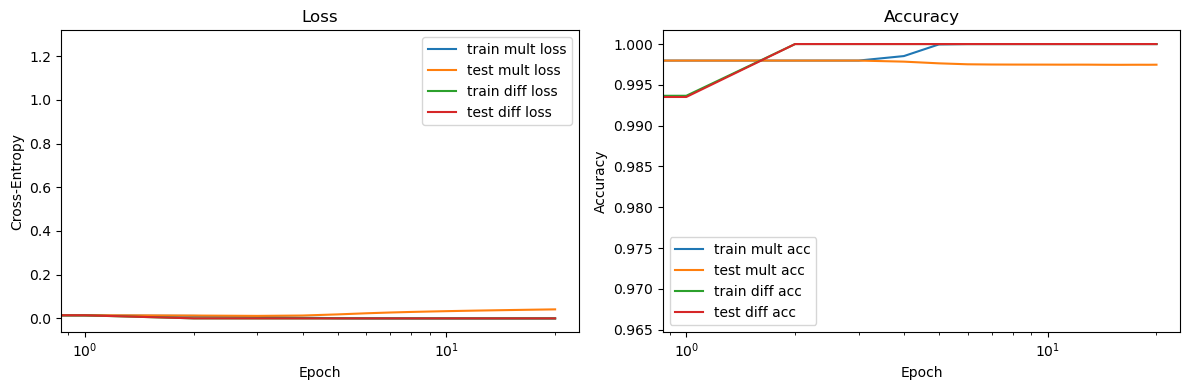

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs=torch.arange(len(hist['train_mul_loss'])).cpu()

axes[0].set_xscale('log')
axes[0].plot(epochs, hist['train_mul_loss'], label="train mult loss")
axes[0].plot(epochs, hist['test_mul_loss'], label="test mult loss")
axes[0].plot(epochs, hist['train_diff_loss'], label="train diff loss")
axes[0].plot(epochs, hist['test_diff_loss'], label="test diff loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-Entropy")
axes[0].legend()

axes[1].set_xscale('log')
axes[1].plot(epochs, hist['train_mul_coeff_acc'], label="train mult acc")
axes[1].plot(epochs, hist['test_mul_coeff_acc'], label="test mult acc")
axes[1].plot(epochs, hist['train_diff_coeff_acc'], label="train diff acc")
axes[1].plot(epochs, hist['test_diff_coeff_acc'], label="test diff acc")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()


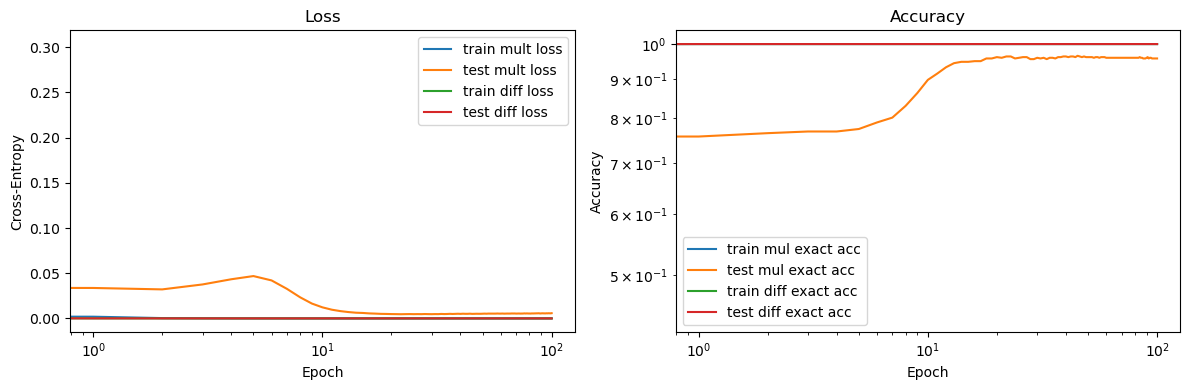

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs = torch.arange(len(hist["train_mul_loss"])).cpu()

axes[0].set_xscale("log")
#axes[0].set_yscale("log")
axes[0].plot(epochs, hist["train_mul_loss"], label="train mult loss")
axes[0].plot(epochs, hist["test_mul_loss"], label="test mult loss")
axes[0].plot(epochs, hist["train_diff_loss"], label="train diff loss")
axes[0].plot(epochs, hist["test_diff_loss"], label="test diff loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-Entropy")
axes[0].legend()

axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].plot(epochs, hist["train_mul_exact_acc"], label="train mul exact acc")
axes[1].plot(epochs, hist["test_mul_exact_acc"], label="test mul exact acc")
axes[1].plot(epochs, hist["train_diff_exact_acc"], label="train diff exact acc")
axes[1].plot(epochs, hist["test_diff_exact_acc"], label="test diff exact acc")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()


In [12]:
@torch.no_grad()
def check_leibniz_rule(model, p, q, device, batch_size=512, return_failures=10):
    """
    Check how well the learned multiplication and differential satisfy

        d(a b) = d(a) b + (-1)^{|a|} a d(b)

    on all pairs of basis elements.

    Assumes:
    - build_basis_tensor(q, device)
    - the model uses op=0 for multiplication and op=1 for differential
    - multiplication output is a coefficient vector in the basis
    - differential output is also a coefficient vector in the basis
    """
    model.eval()

    basis = build_basis_tensor(q=q, device=device)
    D = basis.shape[0]
    dummy = D

    def predict_mul_table():
        pairs = torch.cartesian_prod(
            torch.arange(D, device=device),
            torch.arange(D, device=device),
        )
        out = []
        for start in range(0, pairs.shape[0], batch_size):
            batch = pairs[start:start + batch_size]
            op = torch.zeros(batch.shape[0], dtype=torch.long, device=device)
            logits = model(op, batch[:, 0], batch[:, 1])
            out.append(logits.argmax(dim=-1))
        return torch.cat(out, dim=0).view(D, D, D).long()

    def predict_diff_table():
        idx = torch.arange(D, device=device)
        out = []
        for start in range(0, D, batch_size):
            batch = idx[start:start + batch_size]
            op = torch.ones(batch.shape[0], dtype=torch.long, device=device)
            right = torch.full((batch.shape[0],), dummy, dtype=torch.long, device=device)
            logits = model(op, batch, right)
            out.append(logits.argmax(dim=-1))
        return torch.cat(out, dim=0).long()

    def diff_vectors(vecs, diff_table):
        return torch.einsum("bi,id->bd", vecs, diff_table) % p

    def mul_vectors(left_vecs, right_vecs, mul_table):
        return torch.einsum("bi,bj,ijd->bd", left_vecs, right_vecs, mul_table) % p

    mul_table = predict_mul_table()
    diff_table = predict_diff_table()

    pairs = torch.cartesian_prod(
        torch.arange(D, device=device),
        torch.arange(D, device=device),
    )
    left_idx = pairs[:, 0]
    right_idx = pairs[:, 1]

    basis_vecs = torch.eye(D, dtype=torch.long, device=device)
    left_basis = basis_vecs[left_idx]
    right_basis = basis_vecs[right_idx]

    ab = mul_table[left_idx, right_idx]
    lhs = diff_vectors(ab, diff_table)

    da = diff_table[left_idx]
    db = diff_table[right_idx]
    da_b = mul_vectors(da, right_basis, mul_table)
    a_db = mul_vectors(left_basis, db, mul_table)

    parity = (basis[left_idx, 2] + basis[left_idx, 3]) % 2
    signed_a_db = torch.where(parity[:, None] == 1, ((p - 1) * a_db) % p, a_db)
    rhs = (da_b + signed_a_db) % p

    coeff_match = (lhs == rhs)
    pair_match = coeff_match.all(dim=1)
    mismatches_per_pair = (~coeff_match).sum(dim=1)

    failed = torch.where(~pair_match)[0]
    failure_examples = []
    for idx in failed[:return_failures].tolist():
        i = left_idx[idx].item()
        j = right_idx[idx].item()
        failure_examples.append({
            "left_index": i,
            "right_index": j,
            "left_basis": basis[i].detach().cpu().tolist(),
            "right_basis": basis[j].detach().cpu().tolist(),
            "lhs": lhs[idx].detach().cpu().tolist(),
            "rhs": rhs[idx].detach().cpu().tolist(),
            "n_bad_coeffs": mismatches_per_pair[idx].item(),
        })

    return {
        "n_pairs": pairs.shape[0],
        "exact_fraction": pair_match.float().mean().item(),
        "coeff_fraction": coeff_match.float().mean().item(),
        "n_failed_pairs": failed.numel(),
        "mean_bad_coeffs_per_pair": mismatches_per_pair.float().mean().item(),
        "max_bad_coeffs_in_pair": mismatches_per_pair.max().item(),
        "failure_examples": failure_examples,
    }


In [13]:
leibniz_stats = check_leibniz_rule(md, p=3, q=3, device=device)

In [15]:
print(leibniz_stats['exact_fraction'])
print(leibniz_stats['coeff_fraction'])

0.9745370149612427
0.9992069602012634


In [18]:
print(leibniz_stats['n_failed_pairs'])
print(leibniz_stats['n_pairs'])

33
1296


In [33]:
for eg in leibniz_stats['failure_examples']:
    print(eg['n_bad_coeffs'])

1
1
1
1
1
1
1
1
1
2


In [32]:
print(len(leibniz_stats['failure_examples']))

10


In [69]:
def build_mul_feature_dataset_tensor(p=5, q=5, frac=0.6, batch_size=None, seed=0, device="cpu"):
    basis = build_basis_tensor(q=q, device=device)
    D = basis.shape[0]
    mul_targets = build_mul_targets_tensor(basis, p=p, q=q)

    pairs = torch.cartesian_prod(
        torch.arange(D, device=device),
        torch.arange(D, device=device),
    )

    left_idx = pairs[:, 0]
    right_idx = pairs[:, 1]

    left_feat = basis[left_idx]
    right_feat = basis[right_idx]
    targets = mul_targets[left_idx, right_idx]

    dataset = TensorDataset(left_feat, right_feat, targets)

    n = len(dataset)
    n_train = int(frac * n)
    n_test = n - n_train

    gen = torch.Generator().manual_seed(seed)
    train_dataset, test_dataset = random_split(dataset, [n_train, n_test], generator=gen)

    if batch_size is None:
        train_batch_size = n_train
        test_batch_size = n_test
    else:
        train_batch_size = batch_size
        test_batch_size = batch_size

    train_loader = DataLoader(train_dataset, batch_size=train_batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=test_batch_size, shuffle=False)

    return {
        "basis": basis,
        "D": D,
        "mul_targets": mul_targets,
        "train_loader": train_loader,
        "test_loader": test_loader,
    }


In [71]:
@torch.no_grad()
def evaluate_mul_feature_model(model, loader, p, device):
    model.eval()

    total_loss = 0.0
    total_n = 0
    total_coeff_acc = 0.0
    total_exact_acc = 0.0

    for left_feat, right_feat, target in loader:
        left_feat = left_feat.to(device)
        right_feat = right_feat.to(device)
        target = target.to(device)

        logits = model(left_feat, right_feat)

        loss = F.cross_entropy(
            logits.reshape(-1, p),
            target.reshape(-1),
        )

        pred = logits.argmax(dim=-1)
        coeff_acc = (pred == target).float().mean()
        exact_acc = (pred == target).all(dim=1).float().mean()

        batch_n = left_feat.shape[0]
        total_loss += loss.item() * batch_n
        total_coeff_acc += coeff_acc.item() * batch_n
        total_exact_acc += exact_acc.item() * batch_n
        total_n += batch_n

    return {
        "mul_loss": total_loss / total_n,
        "mul_coeff_acc": total_coeff_acc / total_n,
        "mul_exact_acc": total_exact_acc / total_n,
    }


In [90]:
def train_mul_feature_model(
    p=5,
    q=5,
    frac=0.6,
    batch_size=256,
    hid_dim=128,
    lr=1e-3,
    weight_decay=1e-4,
    n_epochs=2000,
    seed=0,
    device="cpu",
):
    data = build_mul_feature_dataset_tensor(
        p=p,
        q=q,
        frac=frac,
        batch_size=batch_size,
        seed=seed,
        device=device,
    )
    D = data["D"]

    model = DGMultFeatureModel(D=D, p=p, hid_dim=hid_dim).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = {
        "train_mul_loss": [],
        "test_mul_loss": [],
        "train_mul_coeff_acc": [],
        "test_mul_coeff_acc": [],
        "train_mul_exact_acc": [],
        "test_mul_exact_acc": [],
    }

    for epoch in range(n_epochs):
        model.train()

        for left_feat, right_feat, target in data["train_loader"]:
            left_feat = left_feat.to(device)
            right_feat = right_feat.to(device)
            target = target.to(device)

            optimizer.zero_grad()
            logits = model(left_feat, right_feat)

            loss = F.cross_entropy(
                logits.reshape(-1, p),
                target.reshape(-1),
            )
            loss.backward()
            optimizer.step()

        if (epoch + 1) % 500 == 0 or epoch == 0:
            train_metrics = evaluate_mul_feature_model(model, data["train_loader"], p, device)
            test_metrics = evaluate_mul_feature_model(model, data["test_loader"], p, device)

            history["train_mul_loss"].append(train_metrics["mul_loss"])
            history["test_mul_loss"].append(test_metrics["mul_loss"])
            history["train_mul_coeff_acc"].append(train_metrics["mul_coeff_acc"])
            history["test_mul_coeff_acc"].append(test_metrics["mul_coeff_acc"])
            history["train_mul_exact_acc"].append(train_metrics["mul_exact_acc"])
            history["test_mul_exact_acc"].append(test_metrics["mul_exact_acc"])

            print(
                f"epoch={epoch+1:6d} | "
                f"train_mul_loss={train_metrics['mul_loss']:.4f} | "
                f"test_mul_loss={test_metrics['mul_loss']:.4f} | "
                f"train_mul_exact_acc={train_metrics['mul_exact_acc']:.4f} | "
                f"test_mul_exact_acc={test_metrics['mul_exact_acc']:.4f}"
            )

    return model, data, history

In [93]:
md_feat, data_feat, hist_feat = train_mul_feature_model(
    p=2,
    q=2,
    frac=0.4,
    batch_size=None,
    hid_dim=300,
    lr=1e-3,
    weight_decay=0.5,
    n_epochs=40000,
    seed=0,
    device=device,
)


epoch=     1 | train_mul_loss=0.6739 | test_mul_loss=0.6732 | train_mul_exact_acc=0.0000 | test_mul_exact_acc=0.0000
epoch=   500 | train_mul_loss=0.0720 | test_mul_loss=0.0851 | train_mul_exact_acc=0.6471 | test_mul_exact_acc=0.7078
epoch=  1000 | train_mul_loss=0.0428 | test_mul_loss=0.0902 | train_mul_exact_acc=0.7353 | test_mul_exact_acc=0.6753
epoch=  1500 | train_mul_loss=0.0222 | test_mul_loss=0.0983 | train_mul_exact_acc=0.8922 | test_mul_exact_acc=0.6558
epoch=  2000 | train_mul_loss=0.0120 | test_mul_loss=0.1031 | train_mul_exact_acc=0.9804 | test_mul_exact_acc=0.6948
epoch=  2500 | train_mul_loss=0.0076 | test_mul_loss=0.1087 | train_mul_exact_acc=1.0000 | test_mul_exact_acc=0.7143
epoch=  3000 | train_mul_loss=0.0058 | test_mul_loss=0.1143 | train_mul_exact_acc=1.0000 | test_mul_exact_acc=0.7273
epoch=  3500 | train_mul_loss=0.0043 | test_mul_loss=0.1191 | train_mul_exact_acc=1.0000 | test_mul_exact_acc=0.7403
epoch=  4000 | train_mul_loss=0.0032 | test_mul_loss=0.1210 | tr

I wanna repeat the treatment but for $n=1$ only and a single $p$.

In [2]:
#because there is no canonical way of identifying the order of elements, build the explicit indexing, where each basis element is a tuple with 
#the first two powers being the bosonic ones and the last two the fermionic
def build_basis_tensor_sing(p=5, device="cpu"):
    vals = torch.cartesian_prod(
        torch.arange(p, device=device),
        torch.arange(2, device=device),
    )
    # columns: a1, e1
    return vals.long()

def basis_index_tensor_sing(a1, e1, p):
    return (a1 * 2 + e1).long()



def build_mul_targets_tensor_sing(basis, p=5):
    device = basis.device
    D = basis.shape[0]

    left = basis[:, None, :]   # [D, 1, 2]
    right = basis[None, :, :]  # [1, D, 2]

    a1 = left[..., 0] #[D,1]
    e1 = left[..., 1] #[D,1]

    b1 = right[..., 0] #[1,D]
    f1 = right[..., 1] #[1,D]

    c1 = a1 + b1 #[D,D]

    g1 = e1 + f1 #[D,D]

    valid = (c1 < p) & (g1 < 2) #[D,D]; basically here are the non-zero basis elements

    # exterior sign: theta2 from left crossing theta1 from right
    inversions = torch.zeros(D,D,device=device) #[D,D]
    coeff = torch.ones_like(c1)
    coeff[inversions % 2 == 1] = p - 1

    out_idx = basis_index_tensor_sing(c1.clamp(max=p-1), g1.clamp(max=1), p) #[D,D]; for each combination of elements return the index of the product

    targets = torch.zeros(D, D, D, dtype=torch.long, device=device)

    ii, jj = torch.where(valid) #this is a boolean [D,D] where the True values are for pairs whose product is non-zero
    targets[ii, jj, out_idx[ii, jj]] = coeff[ii, jj] % p

    return targets

def build_diff_targets_tensor_sing(basis, p=5):
    device = basis.device
    D = basis.shape[0]

    a1 = basis[:, 0] #[D]
    e1 = basis[:, 1]

    targets = torch.zeros(D, D, dtype=torch.long, device=device)

    # theta1 term: d(theta1)=x1
    mask1 = (e1 == 1) & (a1 + 1 < p) #[D]; flag all entries where there is a theta1 and x1 does not vanish after applying differential
    c1 = a1 + 1
    idx1 = basis_index_tensor_sing(c1.clamp(max=p-1), torch.zeros_like(e1), p)

    rows1 = torch.where(mask1)[0] #returns an array of positions where the mask is true
    targets[rows1, idx1[rows1]] = (targets[rows1, idx1[rows1]] + 1) % p

    # # theta2 term: d(theta2)=x2, with sign (-1)^e1
    # mask2 = (e2 == 1) & (a2 + 1 < q)
    # c1 = a1
    # c2 = a2 + 1
    # idx2 = basis_index_tensor(c1, c2.clamp(max=q-1), e1, torch.zeros_like(e2), q)

    # sign2 = torch.where(
    #     e1 == 1,
    #     torch.full_like(e1, p - 1),
    #     torch.ones_like(e1),
    # )

    # rows2 = torch.where(mask2)[0]
    # targets[rows2, idx2[rows2]] = (targets[rows2, idx2[rows2]] + sign2[rows2]) % p

    return targets

In [3]:
from torch.utils.data import TensorDataset, DataLoader, random_split

def build_dg_dataset_tensor_sing(p=5, frac=0.4, batch_size=None, seed=0, device="cpu", diff_repeat=1):
    basis = build_basis_tensor_sing(p=p, device=device)
    D = basis.shape[0]
    dummy = D

    mul_targets = build_mul_targets_tensor_sing(basis, p=p)   # [D, D, D]
    diff_targets = build_diff_targets_tensor_sing(basis, p=p) # [D, D]

    # multiplication examples
    pairs = torch.cartesian_prod(
        torch.arange(D, device=device),
        torch.arange(D, device=device),
    ) #[D^2,2]
    mul_ops = torch.zeros(D * D, dtype=torch.long, device=device)
    mul_left = pairs[:, 0]
    mul_right = pairs[:, 1]
    mul_y = mul_targets[mul_left, mul_right]

    # differential examples
    diff_left_base = torch.arange(D, device=device)
    diff_ops_base = torch.ones(D, dtype=torch.long, device=device)
    diff_right_base = torch.full((D,), dummy, dtype=torch.long, device=device)
    diff_y_base = diff_targets

    if diff_repeat > 1:
        diff_ops = diff_ops_base.repeat(diff_repeat)
        diff_left = diff_left_base.repeat(diff_repeat)
        diff_right = diff_right_base.repeat(diff_repeat)
        diff_y = diff_y_base.repeat(diff_repeat, 1)
    else:
        diff_ops = diff_ops_base
        diff_left = diff_left_base
        diff_right = diff_right_base
        diff_y = diff_y_base

    ops = torch.cat([mul_ops, diff_ops], dim=0)
    lefts = torch.cat([mul_left, diff_left], dim=0)
    rights = torch.cat([mul_right, diff_right], dim=0)
    targets = torch.cat([mul_y, diff_y], dim=0)

    dataset = TensorDataset(ops, lefts, rights, targets)

    n = len(dataset)
    n_train = int(frac * n)
    n_test = n - n_train

    gen = torch.Generator().manual_seed(seed)
    train_dataset, test_dataset = random_split(dataset, [n_train, n_test], generator=gen)

    if batch_size is None:
        train_batch_size = n_train
        test_batch_size = n_test
    else:
        train_batch_size = batch_size
        test_batch_size = batch_size

    train_loader = DataLoader(train_dataset, batch_size=train_batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=test_batch_size, shuffle=False)

    return {
        "basis": basis,
        "D": D,
        "mul_targets": mul_targets,
        "diff_targets": diff_targets,
        "train_loader": train_loader,
        "test_loader": test_loader,
        "dataset": dataset,
    }

In [28]:
class DGModelSing(nn.Module):
    def __init__(self, D, p, emb_dim=128, hid_dim=512, n_ops=2, std=0.1):
        super().__init__()

        self.elem_emb = nn.Embedding(D + 1, emb_dim)  # +1 for dummy
        self.op_emb = nn.Embedding(n_ops, emb_dim)

        self.fc1=nn.Linear(3*emb_dim, hid_dim)
        self.out=nn.Linear(hid_dim,D*p)

        nn.init.normal_(self.elem_emb.weight, mean=0.0, std=std)
        nn.init.normal_(self.op_emb.weight, mean=0.0, std=std)
        nn.init.normal_(self.fc1.weight, mean=0.0, std=std)
        nn.init.normal_(self.out.weight, mean=0.0, std=std)
        
        self.std=std
        self.D = D
        self.p = p

    def forward(self, op, left, right):
        op_e = self.op_emb(op)
        left_e = self.elem_emb(left)
        right_e = self.elem_emb(right)

        h = torch.cat([op_e, left_e, right_e], dim=-1)
        end = self.out(torch.relu(self.fc1(h)))

        return end.view(-1, self.D, self.p) #[batch, D, p]

In [29]:
def coeff_accuracy_sing(logits, targets):
    """
    logits:  [batch, D, p]
    targets: [batch, D]
    """
    pred = logits.argmax(dim=-1)
    return (pred == targets).float().mean()


def vector_exact_accuracy_sing(logits, targets):
    """
    Exact vector accuracy: entire coefficient vector must match.
    """
    pred = logits.argmax(dim=-1)
    return (pred == targets).all(dim=1).float().mean()


@torch.no_grad()
def evaluate_dg_sing(model, loader, p, device):
    model.eval()

    total_loss = 0.0
    total_n = 0

    total_coeff_acc = 0.0
    total_exact_acc = 0.0

    for op, left, right, target in loader:
        op = op.to(device)
        left = left.to(device)
        right = right.to(device)
        target = target.to(device)

        logits = model(op, left, right)

        loss = F.cross_entropy(
            logits.reshape(-1, p),
            target.reshape(-1),
        )

        batch_n = op.shape[0]
        total_loss += loss.item() * batch_n
        total_n += batch_n

        total_coeff_acc += coeff_accuracy_sing(logits, target).item() * batch_n
        total_exact_acc += vector_exact_accuracy_sing(logits, target).item() * batch_n

    return {
        "loss": total_loss / total_n,
        "coeff_acc": total_coeff_acc / total_n,
        "exact_acc": total_exact_acc / total_n,
    }



In [30]:
@torch.no_grad()
def evaluate_dg_by_task_sing(model, loader, p, device):
    model.eval()

    stats = {
        "mul":  {"n": 0, "loss_sum": 0.0, "coeff_sum": 0.0, "exact_sum": 0.0},
        "diff": {"n": 0, "loss_sum": 0.0, "coeff_sum": 0.0, "exact_sum": 0.0},
    }

    for op, left, right, target in loader:
        op = op.to(device)
        left = left.to(device)
        right = right.to(device)
        target = target.to(device)

        logits = model(op, left, right)  # [batch, D, p]
        pred = logits.argmax(dim=-1)     # [batch, D]

        for op_value, name in [(0, "mul"), (1, "diff")]:
            mask = (op == op_value)

            if mask.sum() == 0:
                continue

            logits_t = logits[mask]
            target_t = target[mask]
            pred_t = pred[mask]

            loss_t = F.cross_entropy(
                logits_t.reshape(-1, p),
                target_t.reshape(-1),
            )

            coeff_acc_t = (pred_t == target_t).float().mean()
            exact_acc_t = (pred_t == target_t).all(dim=1).float().mean()

            n_t = mask.sum().item()

            stats[name]["n"] += n_t
            stats[name]["loss_sum"] += loss_t.item() * n_t
            stats[name]["coeff_sum"] += coeff_acc_t.item() * n_t
            stats[name]["exact_sum"] += exact_acc_t.item() * n_t

    out = {}

    for name in ["mul", "diff"]:
        n = stats[name]["n"]

        if n == 0:
            out[f"{name}_loss"] = float("nan")
            out[f"{name}_coeff_acc"] = float("nan")
            out[f"{name}_exact_acc"] = float("nan")
        else:
            out[f"{name}_loss"] = stats[name]["loss_sum"] / n
            out[f"{name}_coeff_acc"] = stats[name]["coeff_sum"] / n
            out[f"{name}_exact_acc"] = stats[name]["exact_sum"] / n

    return out

In [35]:


def train_dg_sing(p=5,frac=0.6,batch_size=256,emb_dim=128,hid_dim=1000,lr=1e-3,weight_decay=1e-2,n_epochs=600,seed=0,device="cpu", std=0.1, diff_repeat=100):

    data = build_dg_dataset_tensor_sing(p=p,frac=frac,batch_size=batch_size,seed=seed,device=device,diff_repeat=diff_repeat)
    D = data["D"]

    model = DGModelSing( D=D, p=p, emb_dim=emb_dim, hid_dim=hid_dim, n_ops=2, std=std).to(device)

    optimizer = torch.optim.AdamW(model.parameters(),lr=lr,weight_decay=weight_decay)

    history = {
        "train_mul_loss": [],
        "test_mul_loss": [],
        "train_diff_loss": [],
        "test_diff_loss": [],
        "train_mul_coeff_acc": [],
        "test_mul_coeff_acc": [],
        "train_mul_exact_acc": [],
        "test_mul_exact_acc": [],
        "train_diff_coeff_acc": [],
        "test_diff_coeff_acc": [],
        "train_diff_exact_acc": [],
        "test_diff_exact_acc": [],
    }

    for epoch in range(n_epochs):
        model.train()

        for op, left, right, target in data["train_loader"]:
            op = op.to(device)
            left = left.to(device)
            right = right.to(device)
            target = target.to(device)

            optimizer.zero_grad()

            logits = model(op, left, right)

            loss = F.cross_entropy(
                logits.reshape(-1, p),
                target.reshape(-1),
            )

            loss.backward()
            optimizer.step()

        if (epoch + 1) % 100 == 0 or epoch == 0:
            train_metrics = evaluate_dg_by_task_sing(model, data["train_loader"], p, device)
            test_metrics = evaluate_dg_by_task_sing(model, data["test_loader"], p, device)

            history["train_mul_coeff_acc"].append(train_metrics["mul_coeff_acc"])
            history["test_mul_coeff_acc"].append(test_metrics["mul_coeff_acc"])
            history["train_mul_exact_acc"].append(train_metrics["mul_exact_acc"])
            history["test_mul_exact_acc"].append(test_metrics["mul_exact_acc"])

            history["train_diff_coeff_acc"].append(train_metrics["diff_coeff_acc"])
            history["test_diff_coeff_acc"].append(test_metrics["diff_coeff_acc"])
            history["train_diff_exact_acc"].append(train_metrics["diff_exact_acc"])
            history["test_diff_exact_acc"].append(test_metrics["diff_exact_acc"])

            history["train_mul_loss"].append(train_metrics["mul_loss"])
            history["test_mul_loss"].append(test_metrics["mul_loss"])
            history["train_diff_loss"].append(train_metrics["diff_loss"])
            history["test_diff_loss"].append(test_metrics["diff_loss"])


            print(
                f"epoch={epoch+1:6d} | "
                f"train_mul_loss={train_metrics['mul_loss']:.4f} | "
                f"test_mul_loss={test_metrics['mul_loss']:.4f} | "
                f"train_mul_exact_acc={train_metrics["mul_exact_acc"]:.4f} | "
                f"test_mul_exact_acc={test_metrics["mul_exact_acc"]:.4f} | "
                f"train_diff_exact_acc={train_metrics["diff_exact_acc"]:.4f} | "
                f"test_diff_exact_acc={test_metrics["diff_exact_acc"]:.4f}"
            )

    return model, data, history

In [47]:
md, data, hist=train_dg_sing(p=29, frac=0.7, batch_size=256,n_epochs=6000,device=device, std=0.001, diff_repeat=5, weight_decay=1e-2, hid_dim=800)

epoch=     1 | train_mul_loss=2.9446 | test_mul_loss=2.9448 | train_mul_exact_acc=0.6118 | test_mul_exact_acc=0.6126 | train_diff_exact_acc=0.5095 | test_diff_exact_acc=0.5375
epoch=   100 | train_mul_loss=0.0351 | test_mul_loss=0.0360 | train_mul_exact_acc=0.6118 | test_mul_exact_acc=0.6126 | train_diff_exact_acc=0.5095 | test_diff_exact_acc=0.5375
epoch=   200 | train_mul_loss=0.0345 | test_mul_loss=0.0355 | train_mul_exact_acc=0.6118 | test_mul_exact_acc=0.6126 | train_diff_exact_acc=0.5095 | test_diff_exact_acc=0.5375
epoch=   300 | train_mul_loss=0.0331 | test_mul_loss=0.0343 | train_mul_exact_acc=0.6118 | test_mul_exact_acc=0.6126 | train_diff_exact_acc=0.5095 | test_diff_exact_acc=0.5375
epoch=   400 | train_mul_loss=0.0247 | test_mul_loss=0.0271 | train_mul_exact_acc=0.6118 | test_mul_exact_acc=0.6126 | train_diff_exact_acc=0.5095 | test_diff_exact_acc=0.5375
epoch=   500 | train_mul_loss=0.0129 | test_mul_loss=0.0170 | train_mul_exact_acc=0.6272 | test_mul_exact_acc=0.6244 | t

KeyboardInterrupt: 

In [4]:
def enumerate_fp_vectors(dim, p, device="cpu"):
    ids = torch.arange(p ** dim, device=device, dtype=torch.long)
    powers = (p ** torch.arange(dim, device=device, dtype=torch.long)).view(1, dim)
    return ((ids.view(-1, 1) // powers) % p).long()


def coeffs_to_element_id(coeffs, p):
    dim = coeffs.shape[-1]
    powers = (p ** torch.arange(dim, device=coeffs.device, dtype=torch.long)).view(*([1] * (coeffs.ndim - 1)), dim)
    return (coeffs.long() * powers).sum(dim=-1)


def element_id_to_coeffs(ids, p, dim):
    powers = (p ** torch.arange(dim, device=ids.device, dtype=torch.long)).view(*([1] * ids.ndim), dim)
    return ((ids.unsqueeze(-1) // powers) % p).long()


def build_structure_tensor_dg_paper(p=3, device="cpu"):
    basis = build_basis_tensor_sing(p=p, device=device)
    return build_mul_targets_tensor_sing(basis, p=p)


def multiply_element_batches_paper(left_coeffs, right_coeffs, C, p):
    prod = torch.einsum(
        "bi,qj,ijk->bqk",
        left_coeffs.float(),
        right_coeffs.float(),
        C.float(),
    )
    return (prod.round().long() % p)


def apply_diff_to_elements_paper(coeffs, diff_basis, p):
    diff = torch.einsum(
        "bi,ij->bj",
        coeffs.float(),
        diff_basis.float(),
    )
    return (diff.round().long() % p)


def build_dg_dataset_tensor_paper(p=3, frac=0.5, batch_size=None, seed=0, device="cpu", pair_chunk_size=64, diff_repeat=1):
    basis = build_basis_tensor_sing(p=p, device=device)
    C = build_mul_targets_tensor_sing(basis, p=p)
    diff_basis = build_diff_targets_tensor_sing(basis, p=p)
    D = basis.shape[0]
    dummy = p ** D

    elements = enumerate_fp_vectors(D, p, device=device)
    qA = elements.shape[0]

    op_chunks = []
    left_ids_chunks = []
    right_ids_chunks = []
    target_ids_chunks = []

    all_right_ids = torch.arange(qA, device=device, dtype=torch.long)

    for start in range(0, qA, pair_chunk_size):
        stop = min(start + pair_chunk_size, qA)
        left_ids = torch.arange(start, stop, device=device, dtype=torch.long)
        left_coeffs = elements[left_ids]

        prod_coeffs = multiply_element_batches_paper(left_coeffs, elements, C, p)
        prod_ids = coeffs_to_element_id(prod_coeffs, p).reshape(-1)

        left_grid = left_ids[:, None].expand(-1, qA).reshape(-1)
        right_grid = all_right_ids[None, :].expand(stop - start, -1).reshape(-1)

        op_chunks.append(torch.zeros_like(left_grid))
        left_ids_chunks.append(left_grid)
        right_ids_chunks.append(right_grid)
        target_ids_chunks.append(prod_ids)

    diff_left_base = torch.arange(qA, device=device, dtype=torch.long)
    diff_right_base = torch.full((qA,), dummy, device=device, dtype=torch.long)
    diff_target_base = coeffs_to_element_id(apply_diff_to_elements_paper(elements, diff_basis, p), p)

    if diff_repeat > 1:
        diff_ops = torch.ones(qA * diff_repeat, device=device, dtype=torch.long)
        diff_left = diff_left_base.repeat(diff_repeat)
        diff_right = diff_right_base.repeat(diff_repeat)
        diff_target = diff_target_base.repeat(diff_repeat)
    else:
        diff_ops = torch.ones(qA, device=device, dtype=torch.long)
        diff_left = diff_left_base
        diff_right = diff_right_base
        diff_target = diff_target_base

    op_all = torch.cat(op_chunks + [diff_ops], dim=0)
    left_all = torch.cat(left_ids_chunks + [diff_left], dim=0)
    right_all = torch.cat(right_ids_chunks + [diff_right], dim=0)
    target_all = torch.cat(target_ids_chunks + [diff_target], dim=0)

    dataset = TensorDataset(op_all, left_all, right_all, target_all)

    n = len(dataset)
    n_train = int(frac * n)
    n_test = n - n_train

    gen = torch.Generator().manual_seed(seed)
    train_dataset, test_dataset = random_split(dataset, [n_train, n_test], generator=gen)

    if batch_size is None:
        train_batch_size = n_train
        test_batch_size = n_test
    else:
        train_batch_size = batch_size
        test_batch_size = batch_size

    train_loader = DataLoader(train_dataset, batch_size=train_batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=test_batch_size, shuffle=False)

    return {
        "basis": basis,
        "C": C,
        "diff_basis": diff_basis,
        "D": D,
        "dummy": dummy,
        "qA": qA,
        "elements": elements,
        "train_loader": train_loader,
        "test_loader": test_loader,
        "dataset": dataset,
    }


class DGPaperStyleModel(nn.Module):
    def __init__(self, qA, emb_dim=128, hid_dim=256, n_ops=2, std=0.02):
        super().__init__()
        self.elem_emb = nn.Embedding(qA + 1, emb_dim)
        self.op_emb = nn.Embedding(n_ops, emb_dim)
        self.fc1 = nn.Linear(3 * emb_dim, hid_dim)
        self.out = nn.Linear(hid_dim, qA)

        nn.init.normal_(self.elem_emb.weight, mean=0.0, std=std)
        nn.init.normal_(self.op_emb.weight, mean=0.0, std=std)
        nn.init.normal_(self.fc1.weight, mean=0.0, std=std)
        nn.init.normal_(self.out.weight, mean=0.0, std=std)

    def forward(self, op_ids, left_ids, right_ids):
        op_e = self.op_emb(op_ids)
        left_e = self.elem_emb(left_ids)
        right_e = self.elem_emb(right_ids)
        h = torch.cat([op_e, left_e, right_e], dim=-1)
        return self.out(torch.relu(self.fc1(h)))


@torch.no_grad()
def evaluate_dg_paper(model, loader, device):
    model.eval()

    total_loss = 0.0
    total_acc = 0.0
    total_n = 0

    for op_ids, left_ids, right_ids, target_ids in loader:
        op_ids = op_ids.to(device)
        left_ids = left_ids.to(device)
        right_ids = right_ids.to(device)
        target_ids = target_ids.to(device)

        logits = model(op_ids, left_ids, right_ids)
        loss = F.cross_entropy(logits, target_ids)
        acc = (logits.argmax(dim=-1) == target_ids).float().mean()

        batch_n = left_ids.shape[0]
        total_loss += loss.item() * batch_n
        total_acc += acc.item() * batch_n
        total_n += batch_n

    return {
        "loss": total_loss / total_n,
        "acc": total_acc / total_n,
    }


@torch.no_grad()
def evaluate_dg_paper_by_task(model, loader, device):
    model.eval()

    stats = {
        "mul_loss": 0.0,
        "mul_acc": 0.0,
        "mul_n": 0,
        "diff_loss": 0.0,
        "diff_acc": 0.0,
        "diff_n": 0,
    }

    for op_ids, left_ids, right_ids, target_ids in loader:
        op_ids = op_ids.to(device)
        left_ids = left_ids.to(device)
        right_ids = right_ids.to(device)
        target_ids = target_ids.to(device)

        logits = model(op_ids, left_ids, right_ids)

        for op_value, prefix in [(0, "mul"), (1, "diff")]:
            mask = (op_ids == op_value)
            if mask.sum() == 0:
                continue

            masked_logits = logits[mask]
            masked_targets = target_ids[mask]
            batch_n = masked_targets.shape[0]

            loss = F.cross_entropy(masked_logits, masked_targets)
            acc = (masked_logits.argmax(dim=-1) == masked_targets).float().mean()

            stats[f"{prefix}_loss"] += loss.item() * batch_n
            stats[f"{prefix}_acc"] += acc.item() * batch_n
            stats[f"{prefix}_n"] += batch_n

    out = {}
    for prefix in ["mul", "diff"]:
        if stats[f"{prefix}_n"] > 0:
            out[f"{prefix}_loss"] = stats[f"{prefix}_loss"] / stats[f"{prefix}_n"]
            out[f"{prefix}_acc"] = stats[f"{prefix}_acc"] / stats[f"{prefix}_n"]
        else:
            out[f"{prefix}_loss"] = float("nan")
            out[f"{prefix}_acc"] = float("nan")

    return out


def train_dg_paper(p=3, frac=0.5, batch_size=None, emb_dim=128, hid_dim=256, lr=1e-3, weight_decay=1e-4, n_epochs=500, seed=0, device="cpu", std=0.02, pair_chunk_size=64, log_every=50, diff_repeat=1):
    data = build_dg_dataset_tensor_paper(
        p=p,
        frac=frac,
        batch_size=batch_size,
        seed=seed,
        device=device,
        pair_chunk_size=pair_chunk_size,
        diff_repeat=diff_repeat,
    )
    qA = data["qA"]

    model = DGPaperStyleModel(qA=qA, emb_dim=emb_dim, hid_dim=hid_dim, n_ops=2, std=std).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = {
        "epochs": [],
        "train_mul_loss": [],
        "test_mul_loss": [],
        "train_diff_loss": [],
        "test_diff_loss": [],
        "train_mul_acc": [],
        "test_mul_acc": [],
        "train_diff_acc": [],
        "test_diff_acc": [],
    }

    for epoch in range(n_epochs):
        model.train()

        for op_ids, left_ids, right_ids, target_ids in data["train_loader"]:
            op_ids = op_ids.to(device)
            left_ids = left_ids.to(device)
            right_ids = right_ids.to(device)
            target_ids = target_ids.to(device)

            optimizer.zero_grad()
            logits = model(op_ids, left_ids, right_ids)
            loss = F.cross_entropy(logits, target_ids)
            loss.backward()
            optimizer.step()

        if (epoch + 1) % log_every == 0 or epoch == 0:
            train_metrics = evaluate_dg_paper_by_task(model, data["train_loader"], device)
            test_metrics = evaluate_dg_paper_by_task(model, data["test_loader"], device)

            history["epochs"].append(epoch + 1)
            history["train_mul_loss"].append(train_metrics["mul_loss"])
            history["test_mul_loss"].append(test_metrics["mul_loss"])
            history["train_diff_loss"].append(train_metrics["diff_loss"])
            history["test_diff_loss"].append(test_metrics["diff_loss"])
            history["train_mul_acc"].append(train_metrics["mul_acc"])
            history["test_mul_acc"].append(test_metrics["mul_acc"])
            history["train_diff_acc"].append(train_metrics["diff_acc"])
            history["test_diff_acc"].append(test_metrics["diff_acc"])

            print(
                f"epoch={epoch+1:6d} | "
                f"train_mul_loss={train_metrics['mul_loss']:.4f} | "
                f"test_mul_loss={test_metrics['mul_loss']:.4f} | "
                f"train_diff_loss={train_metrics['diff_loss']:.4f} | "
                f"test_diff_loss={test_metrics['diff_loss']:.4f} | "
                f"train_mul_acc={train_metrics['mul_acc']:.4f} | "
                f"test_mul_acc={test_metrics['mul_acc']:.4f} | "
                f"train_diff_acc={train_metrics['diff_acc']:.4f} | "
                f"test_diff_acc={test_metrics['diff_acc']:.4f}"
            )

    return model, data, history


In [9]:
md, data, hist=train_dg_paper(p=2, log_every=1000, n_epochs=30000, weight_decay=1, frac=0.65, batch_size=17, device=device)

epoch=     1 | train_loss=2.7402 | test_loss=2.7529 | train_acc=0.2289 | test_acc=0.2000
epoch=  1000 | train_loss=0.0005 | test_loss=1.0377 | train_acc=1.0000 | test_acc=0.7889
epoch=  2000 | train_loss=0.0000 | test_loss=0.3476 | train_acc=1.0000 | test_acc=0.8778
epoch=  3000 | train_loss=0.0000 | test_loss=0.2560 | train_acc=1.0000 | test_acc=0.9111
epoch=  4000 | train_loss=0.0000 | test_loss=0.1854 | train_acc=1.0000 | test_acc=0.9444
epoch=  5000 | train_loss=0.0000 | test_loss=0.1602 | train_acc=1.0000 | test_acc=0.9556
epoch=  6000 | train_loss=0.0000 | test_loss=0.1402 | train_acc=1.0000 | test_acc=0.9556
epoch=  7000 | train_loss=0.0000 | test_loss=0.1277 | train_acc=1.0000 | test_acc=0.9556
epoch=  8000 | train_loss=0.0000 | test_loss=0.1034 | train_acc=1.0000 | test_acc=0.9556
epoch=  9000 | train_loss=0.0000 | test_loss=0.0991 | train_acc=1.0000 | test_acc=0.9556
epoch= 10000 | train_loss=0.0000 | test_loss=0.0933 | train_acc=1.0000 | test_acc=0.9556
epoch= 11000 | train_

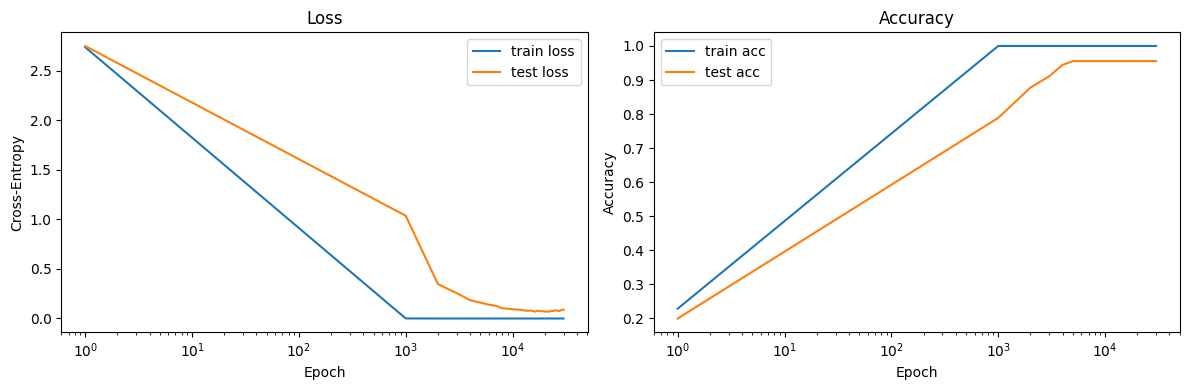

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs = hist['epochs']

axes[0].set_xscale("log")
#axes[0].set_yscale("log")
axes[0].plot(epochs, hist["train_mul_loss"], label="train mul loss")
axes[0].plot(epochs, hist["test_mul_loss"], label="test mul loss")
axes[0].plot(epochs, hist["train_diff_loss"], label="train diff loss")
axes[0].plot(epochs, hist["test_diff_loss"], label="test diff loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-Entropy")
axes[0].legend()

axes[1].set_xscale("log")
#axes[1].set_yscale("log")
axes[1].plot(epochs, hist["train_mul_acc"], label="train mul acc")
axes[1].plot(epochs, hist["test_mul_acc"], label="test mul acc")
axes[1].plot(epochs, hist["train_diff_acc"], label="train diff acc")
axes[1].plot(epochs, hist["test_diff_acc"], label="test diff acc")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()


In [13]:
md2, data2, hist2=train_dg_paper(p=2, log_every=1000, n_epochs=30000, weight_decay=1, frac=0.65, batch_size=15, device=device)

epoch=     1 | train_loss=2.7353 | test_loss=2.7552 | train_acc=0.1687 | test_acc=0.1333
epoch=  1000 | train_loss=0.0016 | test_loss=1.0786 | train_acc=1.0000 | test_acc=0.8333
epoch=  2000 | train_loss=0.0006 | test_loss=1.0606 | train_acc=1.0000 | test_acc=0.8111
epoch=  3000 | train_loss=0.0002 | test_loss=1.2495 | train_acc=1.0000 | test_acc=0.8333
epoch=  4000 | train_loss=0.0004 | test_loss=1.2614 | train_acc=1.0000 | test_acc=0.8333
epoch=  5000 | train_loss=0.0008 | test_loss=1.0541 | train_acc=1.0000 | test_acc=0.8222
epoch=  6000 | train_loss=0.0011 | test_loss=1.0356 | train_acc=1.0000 | test_acc=0.8222
epoch=  7000 | train_loss=0.0017 | test_loss=1.1103 | train_acc=1.0000 | test_acc=0.8444
epoch=  8000 | train_loss=0.0003 | test_loss=1.1183 | train_acc=1.0000 | test_acc=0.8778
epoch=  9000 | train_loss=0.0005 | test_loss=1.0954 | train_acc=1.0000 | test_acc=0.8667
epoch= 10000 | train_loss=0.0004 | test_loss=0.8952 | train_acc=1.0000 | test_acc=0.8556
epoch= 11000 | train_

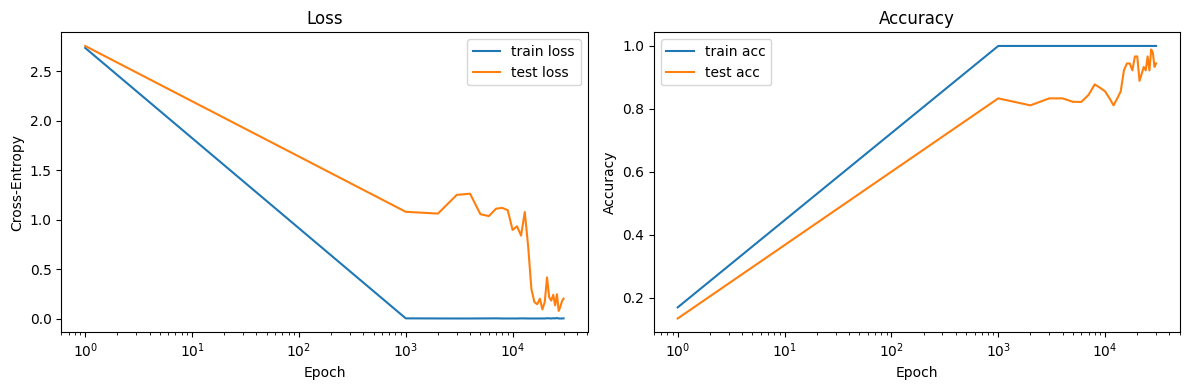

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs2 = hist2['epochs']

axes[0].set_xscale("log")
#axes[0].set_yscale("log")
axes[0].plot(epochs2, hist2["train_mul_loss"], label="train mul loss")
axes[0].plot(epochs2, hist2["test_mul_loss"], label="test mul loss")
axes[0].plot(epochs2, hist2["train_diff_loss"], label="train diff loss")
axes[0].plot(epochs2, hist2["test_diff_loss"], label="test diff loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-Entropy")
axes[0].legend()

axes[1].set_xscale("log")
#axes[1].set_yscale("log")
axes[1].plot(epochs2, hist2["train_mul_acc"], label="train mul acc")
axes[1].plot(epochs2, hist2["test_mul_acc"], label="test mul acc")
axes[1].plot(epochs2, hist2["train_diff_acc"], label="train diff acc")
axes[1].plot(epochs2, hist2["test_diff_acc"], label="test diff acc")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()


In [22]:
torch.save(hist2, "hist2.pt")
torch.save(data2, "data2.pt")

In [23]:
import os
os.getcwd()
os.listdir()

['.config', 'data2.pt', 'hist2.pt', 'sample_data']

In [5]:
md, data, hist=train_dg_paper(p=2, log_every=1000, n_epochs=30000, weight_decay=1, frac=0.65, batch_size=15, device=device)

epoch=     1 | train_mul_loss=2.7306 | test_mul_loss=2.7436 | train_diff_loss=2.6798 | test_diff_loss=2.7097 | train_mul_acc=0.2195 | test_mul_acc=0.2174 | train_diff_acc=0.5833 | test_diff_acc=0.2500
epoch=  1000 | train_mul_loss=0.0004 | test_mul_loss=1.1355 | train_diff_loss=0.0003 | test_diff_loss=0.7191 | train_mul_acc=1.0000 | test_mul_acc=0.6739 | train_diff_acc=1.0000 | test_diff_acc=0.5000
epoch=  2000 | train_mul_loss=0.0000 | test_mul_loss=0.3681 | train_diff_loss=0.0000 | test_diff_loss=0.2111 | train_mul_acc=1.0000 | test_mul_acc=0.9130 | train_diff_acc=1.0000 | test_diff_acc=1.0000
epoch=  3000 | train_mul_loss=0.0000 | test_mul_loss=0.2174 | train_diff_loss=0.0000 | test_diff_loss=0.2843 | train_mul_acc=1.0000 | test_mul_acc=0.9565 | train_diff_acc=1.0000 | test_diff_acc=1.0000
epoch=  4000 | train_mul_loss=0.0008 | test_mul_loss=0.2965 | train_diff_loss=0.0012 | test_diff_loss=0.3631 | train_mul_acc=1.0000 | test_mul_acc=0.8696 | train_diff_acc=1.0000 | test_diff_acc=0.

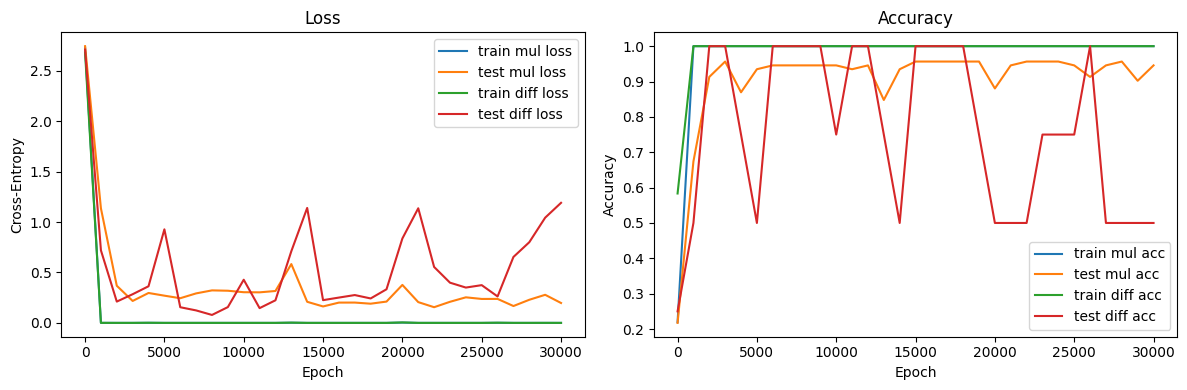

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs = hist['epochs']

#axes[0].set_xscale("log")
#axes[0].set_yscale("log")
axes[0].plot(epochs, hist["train_mul_loss"], label="train mul loss")
axes[0].plot(epochs, hist["test_mul_loss"], label="test mul loss")
axes[0].plot(epochs, hist["train_diff_loss"], label="train diff loss")
axes[0].plot(epochs, hist["test_diff_loss"], label="test diff loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-Entropy")
axes[0].legend()

#axes[1].set_xscale("log")
#axes[1].set_yscale("log")
axes[1].plot(epochs, hist["train_mul_acc"], label="train mul acc")
axes[1].plot(epochs, hist["test_mul_acc"], label="test mul acc")
axes[1].plot(epochs, hist["train_diff_acc"], label="train diff acc")
axes[1].plot(epochs, hist["test_diff_acc"], label="test diff acc")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()
